# OnePixel: Inversión DEM para un solo píxel solar

Este notebook compara tres métodos para resolver la inversión DEM sobre un único píxel:

1. **Red neuronal** (`BasisNetReLU`) entrenada con `BarrierLoss`
2. **Optimización directa** del vector de coeficientes `x` con Adam + softplus
3. **LP clásico** (`fullBP.py`) — Basis Pursuit exacto con HiGHS

Al final se comparan los tres resultados contra el ground truth.

## 1. Imports y configuración

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('..')

import os
from types import SimpleNamespace
import numpy as np
import matplotlib.pyplot as plt
import h5py
from src.utils import processIndDEMData, plotAIACube, processIndAIAData
from src.utils import compute_photon_error_bounds

import torch
import torch.nn as nn

args = {
    "crop": "",
    "dev": "mps",
    "preprocess": "",
    "corr_table": "aia_corr.cvs"
}
args = SimpleNamespace(**args)

# set device
if args.dev == "mps":
    device = torch.device("mps")
elif args.dev == "cuda":
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
device = torch.device("cpu")  # force CPU for now
print("Using device:", device)

wavelengths = [94, 131, 171, 193, 211, 335]

Using device: cpu


## 2. Carga y decodificación de los datos

Los datos están guardados con compresión Blosc + BitRound. Se decodifican los tres cubos:
- `AIACube`: observaciones AIA — shape `[6, H, W]`
- `DEMCube`: DEM de referencia (ground truth) — shape `[18, H, W]`
- `AIAErrors`: errores de ruido fotónico — shape `[6, H, W]`

In [14]:
npz_path = os.path.join(r"..\data\train", "20240520_1200.npz")
npz = np.load(npz_path)
print("npz keys:", npz.files)

npz keys: ['DEMCube', 'DEMCubeShape', 'AIACube', 'AIAErrors', 'AIACubeShape', 'logT', 'scaleFactor']


In [15]:
from numcodecs import Blosc, BitRound

dem_compressor = Blosc(cname='zstd', clevel=5, shuffle=2)
aia_compressor = Blosc(cname='zstd', clevel=4, shuffle=2)
dem_filter = BitRound(keepbits=12)

DEMCubeShape = tuple(npz['DEMCubeShape'])
DEMCube = np.frombuffer(
    dem_filter.decode(dem_compressor.decode(npz['DEMCube'].tobytes())),
    dtype=np.float32
).reshape(DEMCubeShape)

AIACubeShape = tuple(npz['AIACubeShape'])
AIACube = np.frombuffer(
    aia_compressor.decode(npz['AIACube'].tobytes()),
    dtype=np.float32
).reshape(AIACubeShape)

AIAErrors = np.frombuffer(
    aia_compressor.decode(npz['AIAErrors'].tobytes()),
    dtype=np.float32
).reshape(AIACubeShape)

In [16]:
data_path = os.path.join("../data/input/", "20240520_1200")
_, AIAErrors, _= processIndAIAData(data_path, args=args)

reading AIA data from ../data/input/20240520_1200
AIA maps loaded
Exposure times loaded
Correction table %s not found, falling back to JSOC/SSW


c:\Users\Usuario\anaconda3\envs\dem-dl\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


Using correction table from JSOC, cached to aia_corr.cvs
Correction table loaded
Exposure times and degradation factors loaded
Updating pointing and registering AIA maps
Applying degradation correction


In [17]:
print("AIACube:", AIACube.dtype, AIACube.shape)
print("AIAErrors:", AIAErrors.dtype, AIAErrors.shape)
print("DEMCube:", DEMCube.dtype, DEMCube.shape)

AIACube: float32 (6, 4096, 4096)
AIAErrors: float64 (6, 4096, 4096)
DEMCube: float32 (18, 512, 512)


## 3. División en parches y Dataset

El cubo de 4096×4096 se divide en parches de 64×64 (4096 parches en total). Se define un `Dataset` PyTorch que devuelve pares `(aia_patch, aia_error)`.

In [18]:
from src.utils import unfold_tensor
from torch.utils.data import DataLoader, Dataset

aia_patches = unfold_tensor(AIACube)
dem_patches = unfold_tensor(DEMCube, patch_size=32, stride=32)
aia_errors_patches = unfold_tensor(AIAErrors)

In [7]:
print("aia_patches shape:", aia_patches.shape)
print("aia_errors_patches shape:", aia_errors_patches.shape)
print("dem_patches shape:", dem_patches.shape)

aia_patches shape: (256, 6, 256, 256)
aia_errors_patches shape: (256, 6, 256, 256)
dem_patches shape: (256, 18, 32, 32)


In [19]:
class SimpleAIAData(Dataset):
    def __init__(self, data):
        self.aia_ds = data[0]
        self.err_ds = data[1]

    def __getitem__(self, idx):
        aia_patch = torch.from_numpy(self.aia_ds[idx]).double()
        aia_error = torch.from_numpy(self.err_ds[idx]).double()
        return aia_patch, aia_error

    def __len__(self):
        return len(self.aia_ds)

aia_data = SimpleAIAData((aia_patches, aia_errors_patches))

i: 92
aia shape: torch.Size([6, 256, 256])
dem shape: torch.Size([6, 256, 256])


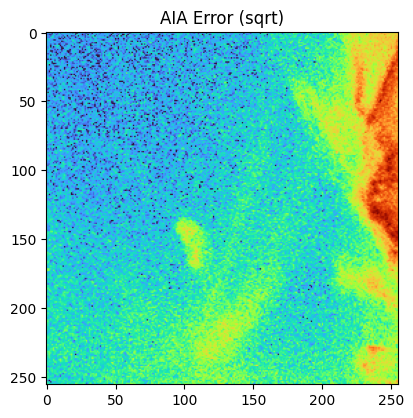

i: 93
aia shape: torch.Size([6, 256, 256])
dem shape: torch.Size([6, 256, 256])


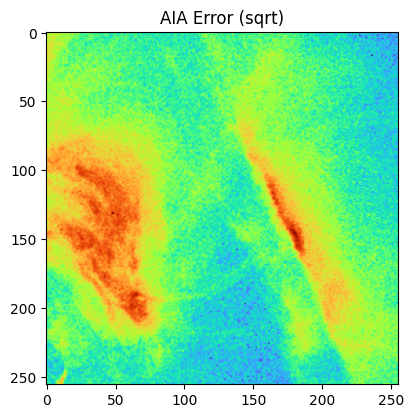

i: 94
aia shape: torch.Size([6, 256, 256])
dem shape: torch.Size([6, 256, 256])


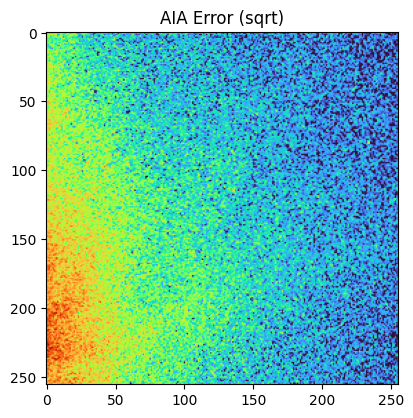

In [20]:
for i, (aia, err) in enumerate(aia_data):
    if i < 92:
        continue
    if i > 94:
        break
    print("i:", i)
    print("aia shape:", aia.shape)
    print("dem shape:", err.shape)
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(err[0]**0.5, cmap="turbo")
    plt.title("AIA Error (sqrt)")
    plt.show()


## 4. Selección del parche de trabajo

Se visualiza el canal 14 de la DEM con los índices de parche para elegir una región interesante. Se trabaja con el **parche 116**.

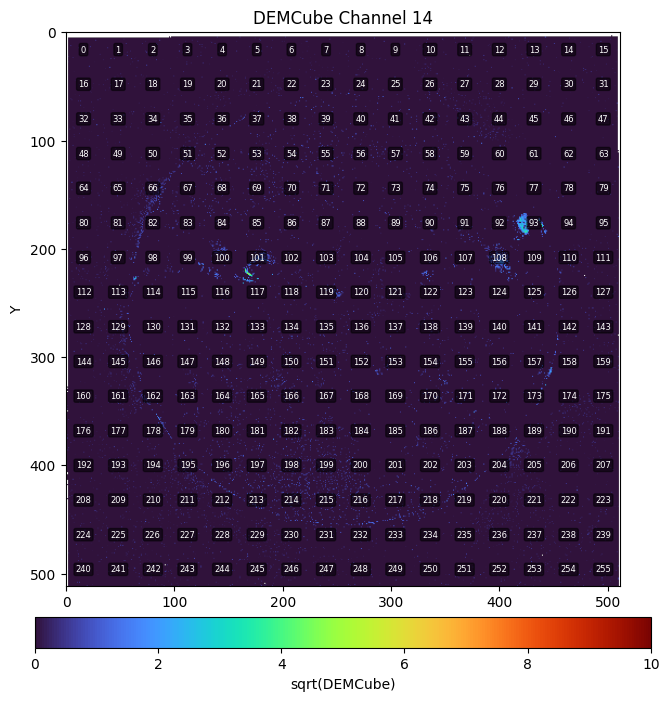

In [21]:
# Plot DEMCube channel 14 with patch labels
channel = 14
patch_size = 32
cube = DEMCube[channel]

plt.figure(figsize=(8, 8))
plt.imshow(cube**0.5, cmap="turbo", vmin=0, vmax=10)
plt.colorbar(label="sqrt(DEMCube)",
            location='bottom',
            orientation='horizontal',
            fraction=0.05,
            pad=0.05)
plt.title(f"DEMCube Channel {channel}")

# Overlay patch labels
n_patches_y = cube.shape[0] // patch_size
n_patches_x = cube.shape[1] // patch_size

for idx_y in range(n_patches_y):
    for idx_x in range(n_patches_x):
        idx = idx_y * n_patches_x + idx_x
        y = idx_y * patch_size + patch_size // 2
        x = idx_x * patch_size + patch_size // 2
        plt.text(x, y, str(idx), color="white", fontsize=6, ha="center", va="center", bbox=dict(facecolor='black', alpha=0.5, boxstyle='round,pad=0.2'))

plt.xlabel("X")
plt.ylabel("Y")
plt.show()

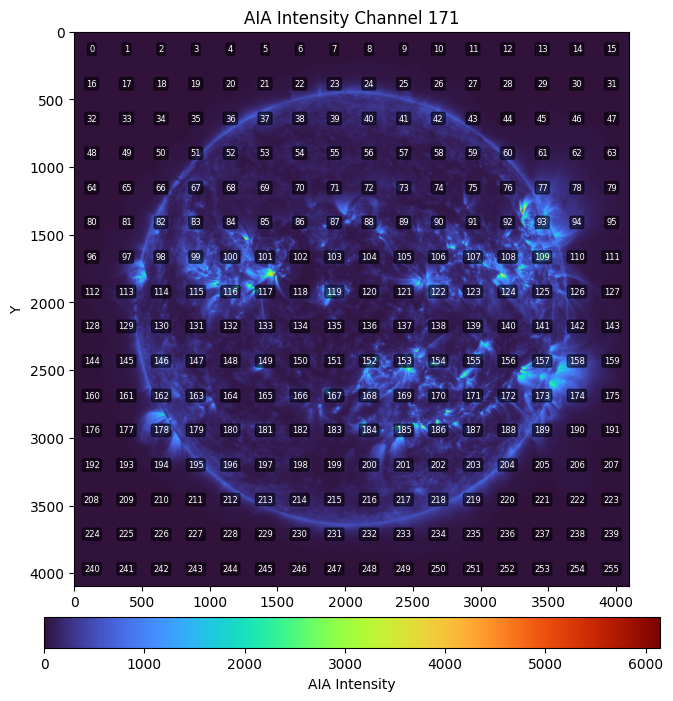

In [26]:
# Plot DEMCube channel 14 with patch labels
wavelengths = [94, 131, 171, 193, 211, 335]
channel = 2  # corresponds to wavelength 171
patch_size = 256
imgs = AIACube[channel]

plt.figure(figsize=(8, 8))
plt.imshow(imgs, cmap="turbo")
plt.colorbar(label="AIA Intensity",
            location='bottom',
            orientation='horizontal',
            fraction=0.05,
            pad=0.05)
plt.title(f"AIA Intensity Channel {wavelengths[channel]}")

# Overlay patch labels
n_patches_y = imgs.shape[0] // patch_size
n_patches_x = imgs.shape[1] // patch_size

for idx_y in range(n_patches_y):
    for idx_x in range(n_patches_x):
        idx = idx_y * n_patches_x + idx_x
        y = idx_y * patch_size + patch_size // 2
        x = idx_x * patch_size + patch_size // 2
        plt.text(x, y, str(idx), color="white", fontsize=6, ha="center", va="center", bbox=dict(facecolor='black', alpha=0.5, boxstyle='round,pad=0.2'))

plt.xlabel("X")
plt.ylabel("Y")
plt.show()

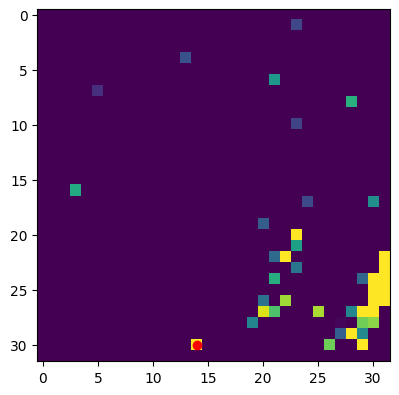

In [24]:
selected_dem = dem_patches[157]
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(selected_dem[14]**0.5, cmap="viridis", vmax=1)
plt.plot(14, 30, 'ro')  # mark the pixel (22, 18) in red
plt.show()

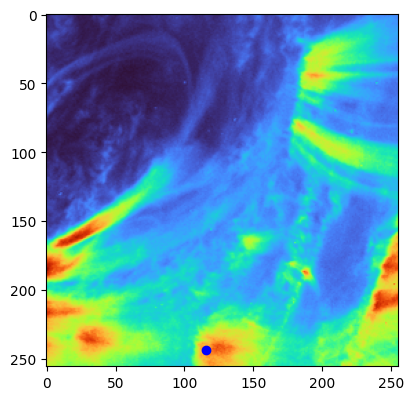

In [28]:
aia, err = aia_data.__getitem__(157)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(aia[channel], cmap="turbo")
plt.plot(14*8+4, 30*8+4, 'bo')  # mark the corresponding pixel in red
plt.show()

## 5. Extracción del píxel de trabajo

Se carga el parche 116 y se extrae el píxel `(100, 100)` como vector de 6 observaciones. Este será el único píxel sobre el que se prueban los tres métodos.

También se guarda el **ground truth** de la DEM para ese píxel (del parche 115 en `dem_patches`, que corresponde al parche 116 del DataLoader por diferencia de indexado).

In [29]:
PATCH_IDX = 157

PIXEL_Y = 14    #(DEMcube Patch (32, 32))
PIXEL_X = 30   #(DEMcube Patch (32, 32))

PIXEL_Y_AIA = PIXEL_Y * 8 + 4  # AIA patch is 256x256, so scale by 8 and add center offset
PIXEL_X_AIA = PIXEL_X * 8 + 4  # AIA patch is 256x256, so scale by 8 and add center offset

aia_ds = torch.utils.data.Subset(aia_data, [PATCH_IDX])
aia_loader = DataLoader(aia_ds, batch_size=1, shuffle=False, num_workers=0)

# extraer el único píxel: shape [1, 6, 1, 1]
aia_input, aia_errors = next(iter(aia_loader))
aia_input  = aia_input[:, :, PIXEL_Y_AIA:PIXEL_Y_AIA+1, PIXEL_X_AIA:PIXEL_X_AIA+1].to(device)
aia_errors = aia_errors[:, :, PIXEL_Y_AIA:PIXEL_Y_AIA+1, PIXEL_X_AIA:PIXEL_X_AIA+1].to(device)

# aplanar para la función de pérdida: shape [1, 6]
aia_obs_flat = aia_input.permute(0, 2, 3, 1).reshape(-1, aia_input.shape[1])

# ground truth para este píxel: shape [18]
dem_true_pixel = dem_patches[PATCH_IDX][:, PIXEL_Y, PIXEL_X]  # [18]

In [30]:
print("Input shape:", aia_input.shape)
print("AIA values:", aia_obs_flat.squeeze().cpu().numpy().round(2))

Input shape: torch.Size([1, 6, 1, 1])
AIA values: [   5.92   51.98  841.88 1697.43  905.96   39.52]


In [32]:
print("DEM BP shape:", dem_true_pixel.shape)
print("DEM BP values:", dem_true_pixel.round(2))

DEM BP shape: (18,)
DEM BP values: [11.36  0.78  1.66  2.45  2.53  1.1   0.22 11.2  32.25 11.2   0.    0.
  0.    0.    0.    0.    0.    0.  ]


## 6. Construcción de la matriz de respuesta $R$ y la base $B$

El modelo físico es $\mathbf{y} = R\boldsymbol{\xi}$, donde:

- $\mathbf{y} \in \mathbb{R}^6$ — intensidades observadas en los 6 canales AIA (DN/s/px)
- $R \in \mathbb{R}^{6 \times 18}$ — matriz de respuesta instrumental; $R_{ij}$ es la sensibilidad del canal $i$ al bin de temperatura $j$
- $\boldsymbol{\xi} \in \mathbb{R}^{18}$ — DEM discretizado en 18 bins de $\log T$

Parametrizamos $\boldsymbol{\xi} = B\mathbf{x}$ con una base de gaussianas, lo que da el sistema efectivo:

$$\mathbf{y} \approx D\mathbf{x}, \quad D = RB \in \mathbb{R}^{6 \times 54}, \quad \mathbf{x} \geq 0$$

donde:
- $B \in \mathbb{R}^{18 \times 54}$ — base de funciones gaussianas centradas en cada bin de $\log T$, con anchos $\alpha \in \{0.0, 0.1, 0.2\}$; permite representar DEMs suaves con pocos coeficientes no nulos
- $\mathbf{x} \in \mathbb{R}^{54}$ — coeficientes de la base, la incógnita del problema ($\mathbf{x} \geq 0$)
- $D = RB \in \mathbb{R}^{6 \times 54}$ — matriz de síntesis efectiva que mapea coeficientes a observaciones

Los límites de la restricción se calculan a partir del ruido fotónico:
$$\mathbf{l} = \mathbf{y} - 1.4\,\sigma, \qquad \mathbf{u} = \mathbf{y} + 1.4\,\sigma, \qquad \sigma_i = \sqrt{\max(y_i,\, 0.5)}$$

In [33]:
RData_np = np.load("../RData.npz")
R_np, logT = RData_np['R'], RData_np['logT']
scale = 10**26
R_np = (R_np * scale).astype(np.float64)

In [34]:
R_np.shape, logT.shape

((6, 18), (18,))

In [35]:
from src.utils import getBasis

basisAlphas = [0.0, 0.1, 0.2]
B_np = getBasis(R_np, logT, basisAlphas)
D_np = R_np @ B_np

RData = {'R': R_np, 'B': B_np}

In [36]:
B_np.shape, D_np.shape

((18, 54), (6, 54))

In [37]:
# versiones torch
R = R_np  # mantener numpy para fullBP
D = torch.tensor(D_np, dtype=torch.float64).to(device)  # [6, 54]
B = torch.tensor(B_np, dtype=torch.float64).to(device)  # [18, 54]

In [38]:
# límites de la restricción
lb, ub = compute_photon_error_bounds(aia_obs=aia_input, aia_errors=aia_errors)
lb = lb.reshape(-1, lb.shape[-1])  # [1, 6]
ub = ub.reshape(-1, ub.shape[-1])  # [1, 6]

print("lb:", lb.squeeze().cpu().numpy().round(2))
print("ub:", ub.squeeze().cpu().numpy().round(2))

lb: [   3.76   43.84  807.95 1644.53  868.49   28.44]
ub: [   8.07   60.13  875.82 1750.33  943.44   50.6 ]


## 7. Función de pérdida compartida: `BarrierLoss`

Los tres métodos basados en gradientes comparten la misma función de pérdida:

$$\mathcal{L}(\mathbf{x}) = \alpha_{L1}\|\mathbf{x}\|_1 + \mu \sum_i \left[\text{relu}(l_i - (D\mathbf{x})_i)^2 + \text{relu}((D\mathbf{x})_i - u_i)^2\right] + \frac{\alpha}{N}\|D\mathbf{x} - \mathbf{I}_{\text{obs}}\|_2^2$$

donde:
- $\mathbf{x} \in \mathbb{R}^{n_{\text{basis}}}$ son los coeficientes de la base DEM
- $D = R B \in \mathbb{R}^{N \times n_{\text{basis}}}$ es la matriz de síntesis
- $l_i, u_i$ son las cotas inferior y superior fotónicas del canal $i$
- $\alpha_{L1}$ controla la sparsidad de la solución
- $\mu$ penaliza las violaciones de las cotas de intervalo
- $\alpha / N$ pondera el ajuste directo a las observaciones AIA $\mathbf{I}_{\text{obs}}$

In [40]:
from src.losses import BarrierLoss

args.alpha_l1 = 1
args.alpha_l2 = 0
args.mu = 1
args.alpha_fit = 0 #without fitting term, we can isolate the effect of the barrier constraint
barrier_loss = BarrierLoss(D=D, B=B, R=R_np, args=args)

---
## MÉTODO 1: Red neuronal `BasisNetReLU`

La red aprende un mapeo directo $f_\theta: \mathbb{R}^6 \to \mathbb{R}^{54}_{\geq 0}$ usando convoluciones 1×1 (equivalentes a un MLP píxel a píxel). La capa final ReLU garantiza $\mathbf{x} \geq 0$.

Se entrena minimizando `BarrierLoss` sobre el único píxel seleccionado.

In [41]:
from src.model import DEMBasisNet, BasisNetReLU

model = BasisNetReLU().double().to(device)
optimizer_net = torch.optim.Adam(model.parameters(), lr=1e-4)

model.train()
for i in range(10000):
    optimizer_net.zero_grad()
    output = model(aia_input)  # [1, 54, 1, 1]
    output_flat = output.permute(0, 2, 3, 1).reshape(-1, output.shape[1])  # [1, 54]

    loss = barrier_loss(output_flat, aia_obs=aia_obs_flat, lb=lb, ub=ub)

    # métricas diagnósticas
    Dx = torch.matmul(output_flat, D.T)
    ub_viol = torch.sum(torch.relu(lb - Dx)).item()
    lb_viol = torch.sum(torch.relu(Dx - ub)).item()

    loss.backward()
    optimizer_net.step()

    if i % 2000 == 0:
        print(f"Step {i:5d} | loss: {loss.item():.4f} | "
              f"L1: {output_flat.sum().item():.4f} | "
              f"UB viol: {ub_viol:.4f} | LB viol: {lb_viol:.4f}")

# predicción final de la red
model.eval()
with torch.no_grad():
    x_net = model(aia_input)  # [1, 54, 1, 1]
    x_net_flat = x_net.permute(0, 2, 3, 1).reshape(-1, x_net.shape[1])  # [1, 54]

print("\nx_net_flat shape:", x_net_flat.shape)
print("L1 norm:", x_net_flat.sum().item())

Step     0 | loss: 276480545.4803 | L1: 356.8053 | UB viol: 0.0000 | LB viol: 26227.8697
Step  2000 | loss: 48.3301 | L1: 48.0217 | UB viol: 0.0263 | LB viol: 0.5547
Step  4000 | loss: 49.2280 | L1: 49.0283 | UB viol: 0.0212 | LB viol: 0.4466
Step  6000 | loss: 52.2878 | L1: 52.1583 | UB viol: 0.0076 | LB viol: 0.3599
Step  8000 | loss: 49.0854 | L1: 48.8952 | UB viol: 0.0227 | LB viol: 0.4355

x_net_flat shape: torch.Size([1, 54])
L1 norm: 89.22518952077256


Now we want to try the training with the fitting term in the loss:

In [42]:
args.alpha_l1 = 1
args.alpha_l2 = 0
args.mu = 1
args.alpha_fit = 1 # now we include the fitting term to see how it interacts with the barrier constraint
barrier_loss_fit = BarrierLoss(D=D, R=R_np, B=B, args=args)

In [43]:
from src.model import DEMBasisNet, BasisNetReLU

model_fit = BasisNetReLU().double().to(device)
optimizer_net = torch.optim.Adam(model_fit.parameters(), lr=1e-4)

model_fit.train()
for i in range(10000):
    optimizer_net.zero_grad()
    output = model_fit(aia_input)  # [1, 54, 1, 1]
    output_flat = output.permute(0, 2, 3, 1).reshape(-1, output.shape[1])  # [1, 54]

    # aia_obs_flat ya está calculado antes del loop: [B*H*W, n_channels]
    loss = barrier_loss(output_flat, aia_obs=aia_obs_flat, lb=lb, ub=ub)

    # métricas diagnósticas
    with torch.no_grad():
        Dx = torch.matmul(output_flat, D.T)
        ub_viol  = torch.sum(torch.relu(lb - Dx)).item()
        lb_viol  = torch.sum(torch.relu(Dx - ub)).item()
        fit_resid = torch.mean((Dx - aia_obs_flat)**2).item()

    loss.backward()
    optimizer_net.step()

    if i % 2000 == 0:
        print(f"Step {i:5d} | loss: {loss.item():.4f} | "
              f"L1: {output_flat.sum().item():.4f} | "
              f"UB viol: {ub_viol:.4f} | LB viol: {lb_viol:.4f} | "
              f"fit MSE: {fit_resid:.4f}")

# predicción final de la red
model_fit.eval()
with torch.no_grad():
    x_net_fit = model_fit(aia_input)  # [1, 54, 1, 1]
    x_net_fit_flat = x_net_fit.permute(0, 2, 3, 1).reshape(-1, x_net_fit.shape[1])  # [1, 54]

    Dx_final   = torch.matmul(x_net_fit_flat, D.T)
    fit_final  = torch.mean((Dx_final - aia_obs_flat)**2).item()
    ub_final   = torch.sum(torch.relu(lb - Dx_final)).item()
    lb_final   = torch.sum(torch.relu(Dx_final - ub)).item()

print("\nx_net_fit_flat shape:", x_net_fit_flat.shape)
print(f"L1 norm:          {x_net_fit_flat.sum().item():.4f}")
print(f"Fit MSE final:    {fit_final:.4f}")
print(f"UB viol final:    {ub_final:.4f}")
print(f"LB viol final:    {lb_final:.4f}")

Step     0 | loss: 356299888.3854 | L1: 297.4977 | UB viol: 0.0000 | LB viol: 25132.6899 | fit MSE: 59693629.7182
Step  2000 | loss: 78.9231 | L1: 76.2714 | UB viol: 0.0453 | LB viol: 1.6280 | fit MSE: 777.0697
Step  4000 | loss: 63.6254 | L1: 62.4717 | UB viol: 0.1971 | LB viol: 1.0643 | fit MSE: 878.9335
Step  6000 | loss: 78.7093 | L1: 73.3502 | UB viol: 0.2254 | LB viol: 3.1406 | fit MSE: 412.9750
Step  8000 | loss: 69.6677 | L1: 68.9023 | UB viol: 0.0607 | LB viol: 0.9475 | fit MSE: 580.3452

x_net_fit_flat shape: torch.Size([1, 54])
L1 norm:          62.8778
Fit MSE final:    807.6457
UB viol final:    0.4786
LB viol final:    0.8901


In [44]:
# forward pass
with torch.no_grad():
    #x_basis = model(aia_input)  # [1, n_basis, H, W]
    #x_basis = x_basis.permute(0, 2, 3, 1).reshape(-1, x_basis.shape[1])  # [N, n_basis]
    dem_pred = torch.matmul(x_net_flat, B.T)  # [N, n_temps]
    # recover dimensions B, 18, H, W
    dem_pred_cube = dem_pred.reshape(aia_input.size(0), aia_input.shape[2], aia_input.shape[3], -1).permute(0, 3, 1, 2).cpu().numpy()  # [B, n_temps, H, W]

print("DEM shape:", dem_pred_cube.shape)

DEM shape: (1, 18, 1, 1)


In [45]:
with torch.no_grad():
    dem_pred_fit = torch.matmul(x_net_fit_flat, B.T)  # [N, n_temps]
    # recover dimensions B, 18, H, W
    dem_pred_fit_cube = dem_pred_fit.reshape(aia_input.size(0), aia_input.shape[2], aia_input.shape[3], -1).permute(0, 3, 1, 2).cpu().numpy()  # [B, n_temps, H, W]
print("DEM fit shape:", dem_pred_fit_cube.shape)

DEM fit shape: (1, 18, 1, 1)


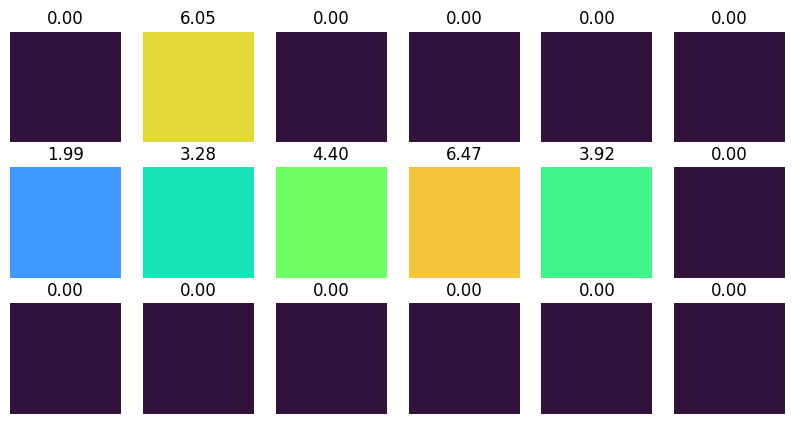

In [46]:
# plot the DEM cube
plt.figure(figsize=(10, 5))

for i in range(18):
    plt.subplot(3, 6, i + 1)
    plt.imshow(dem_pred_cube[0, i]**0.5, cmap="turbo", vmin=0, vmax=10)
    plt.title(f"{dem_pred_cube[0, i, 0, 0]**0.5:.2f}")
    # plot the value in the center
    plt.axis("off")

plt.show()

In [ ]:
dem_true = dem_patches[157]
dem_true = dem_patches[PATCH_IDX][:, PIXEL_Y, PIXEL_X]  # [18]

In [48]:
dem_true = dem_true.reshape(1, -1, 1, 1)  # [1, 18, 1, 1]
dem_true_cube = dem_true.reshape(1, 18, 1, 1)

In [49]:
print("DEM true shape:", dem_true.shape)

DEM true shape: (1, 18, 1, 1)


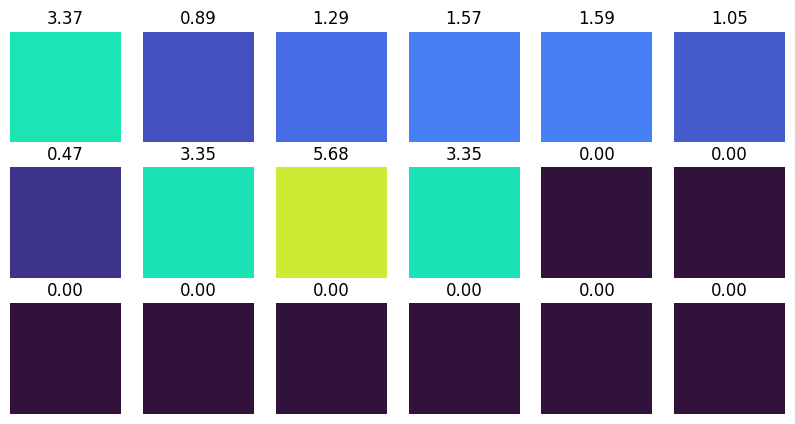

In [50]:
dem_true = dem_patches[157]
dem_true = dem_patches[PATCH_IDX][:, PIXEL_Y, PIXEL_X]  # [18]
# plot the DEM cube
plt.figure(figsize=(10, 5))
for i in range(18):
    plt.subplot(3, 6, i + 1)
    plt.imshow(dem_true_cube[0, i]**0.5, cmap="turbo", vmin=0, vmax=10)
    plt.title(f"{dem_true_cube[0, i, 0, 0]**0.5:.2f}")
    plt.axis("off")

plt.show()

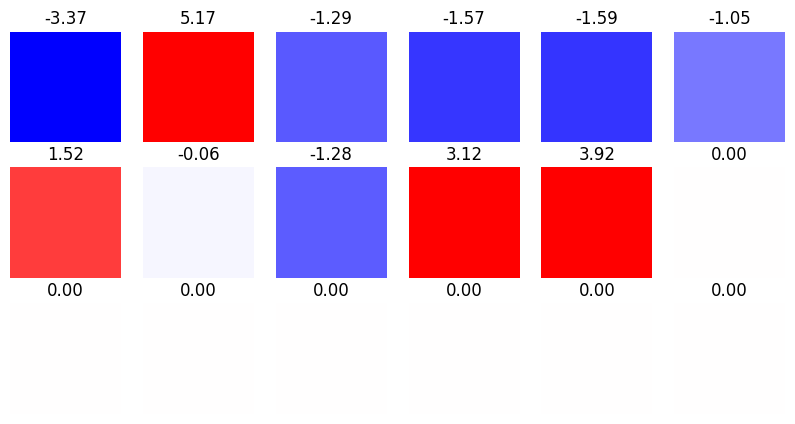

In [51]:
# now, difference, colormap bwr to visualize the difference
plt.figure(figsize=(10, 5))
for i in range(18):
    plt.subplot(3, 6, i + 1)
    diff = dem_pred_cube[0, i, 0, 0]**0.5 - dem_true_cube[0, i, 0, 0]**0.5 # difference at the center pixel
    diff = diff.reshape(1, 1)  # reshape to 2D for imshow
    plt.imshow(diff, cmap="bwr", vmin=-2, vmax=2)
    plt.title(f"{diff[0, 0]:.2f}")
    plt.axis("off")

plt.show()

In [52]:
dem_true

array([11.363281  ,  0.7849121 ,  1.6618652 ,  2.453125  ,  2.5297852 ,
        1.104248  ,  0.22491455, 11.201172  , 32.25      , 11.201172  ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ], dtype=float32)

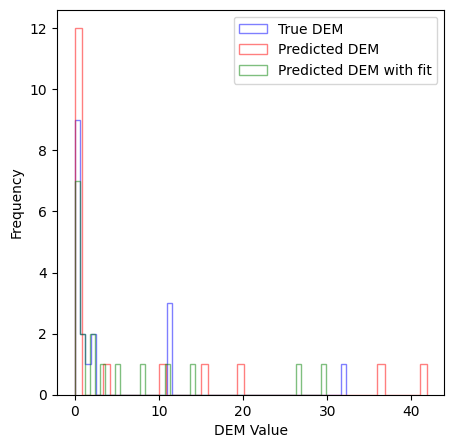

In [53]:
plt.figure(figsize=(5, 5))
plt.hist(dem_true.flatten(), bins=50, color="blue", histtype="step", alpha=0.5, label="True DEM")
plt.hist(dem_pred_cube.flatten(), bins=50, color="red", histtype="step", alpha=0.5, label="Predicted DEM")
plt.hist(dem_pred_fit_cube.flatten(), bins=50, color="green", histtype="step", alpha=0.5, label="Predicted DEM with fit")
plt.xlabel("DEM Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

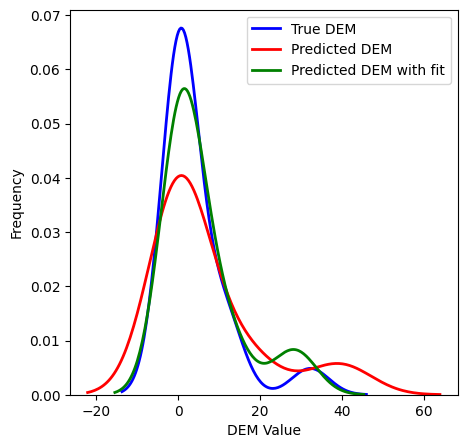

In [54]:
import seaborn as sns

plt.figure(figsize=(5, 5))
sns.kdeplot(dem_true.flatten(), color="blue", linewidth=2, label="True DEM")
sns.kdeplot(dem_pred_cube.flatten(), color="red", linewidth=2, label="Predicted DEM")
sns.kdeplot(dem_pred_fit_cube.flatten(), color="green", linewidth=2, label="Predicted DEM with fit")
plt.xlabel("DEM Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [55]:
mae = np.nanmean(np.abs(dem_pred_cube - dem_true))
mae_fit = np.nanmean(np.abs(dem_pred_fit_cube - dem_true))
print(f"MAE: {mae:.2f}")
print(f"MAE with fit: {mae_fit:.2f}")

MAE: 9.13
MAE with fit: 7.51


In [56]:
# Adapted resynthesis for our case
# dem_pred: [H, W, n_temps], R: [n_channels, n_temps]
# Output: resynth [n_channels, H, W]
n_temps,H, W = dem_pred_cube[0].shape
dem_for_resynth = np.maximum(0, dem_pred_cube[0])  # [H, W, n_temps]
n_channels = R.shape[0]
resynth = np.zeros((n_channels, H, W))
for i in range(H):
    for j in range(W):
        resynth[:, i, j] = R @ dem_for_resynth[:, i, j]

# mae 
mae_resynth = np.nanmean(np.abs(resynth - aia_input[0].cpu().numpy()))
print(f"MAE Resynth: {mae_resynth:.4f}")

MAE Resynth: 35.7093


In [57]:
# mae of ground truth
resynth_gt = np.zeros((n_channels, H, W))
for i in range(H):
    for j in range(W):
        resynth_gt[:, i, j] = R @ dem_true_cube[0, :, i, j]
# mae
mae_gt = np.nanmean(np.abs(resynth_gt - aia_input[0].cpu().numpy()))
print(f"MAE GT: {mae_gt:.4f}")

MAE GT: 29.8822


---
## MÉTODO 2: Optimización directa con Adam + softplus

En lugar de una red, se optimiza directamente el vector $\tilde{\mathbf{x}} \in \mathbb{R}^{54}$ libre, con la reparametrización:

$$\mathbf{x} = \text{softplus}(\tilde{\mathbf{x}}) = \log(1 + e^{\tilde{\mathbf{x}}}) \geq 0$$

Se inicializa desde la predicción de la red (Método 1) aplicando la inversa de softplus, para partir de un buen punto inicial:

$$\tilde{\mathbf{x}}_0 = \text{softplus}^{-1}(\mathbf{x}_\text{net}) = \mathbf{x}_\text{net} + \log(1 - e^{-\mathbf{x}_\text{net}})$$

In [58]:
def inv_softplus(x):
    """Inversa de softplus: softplus^{-1}(x) = x + log(1 - exp(-x))"""
    return x + torch.log(-torch.expm1(-x))

# inicializar desde la predicción de la red, evitando ceros
x_init = x_net_flat.detach().clone()  # [1, 54]
x_init = torch.clamp(x_init, min=1e-4)  # evitar log(0)
x_tilde = torch.nn.Parameter(inv_softplus(x_init))  # parámetro libre [1, 54]

optimizer_direct = torch.optim.Adam([x_tilde], lr=1e-4)

for step in range(50000):
    optimizer_direct.zero_grad()
    x_pos = nn.functional.softplus(x_tilde)  # garantizar x >= 0
    loss = barrier_loss(x_pos, aia_obs=aia_obs_flat, lb=lb, ub=ub)
    loss.backward()
    optimizer_direct.step()

    if step % 10000 == 0:
        Dx = torch.matmul(x_pos.detach(), D.T)
        ub_viol = torch.sum(torch.relu(lb - Dx)).item()
        lb_viol = torch.sum(torch.relu(Dx - ub)).item()
        print(f"Step {step:6d} | loss: {loss.item():.4f} | "
              f"L1: {x_pos.sum().item():.4f} | "
              f"UB viol: {ub_viol:.6f} | LB viol: {lb_viol:.6f}")

# solución final del método directo
x_direct = nn.functional.softplus(x_tilde).detach()  # [1, 54]
print("\nx_direct shape:", x_direct.shape)
print("L1 norm:", x_direct.sum().item())

Step      0 | loss: 2388.8570 | L1: 89.2303 | UB viol: 12.064045 | LB viol: 56.369108
Step  10000 | loss: 2380.3210 | L1: 89.1743 | UB viol: 12.319868 | LB viol: 56.075992
Step  20000 | loss: 2355.1620 | L1: 89.0695 | UB viol: 12.254166 | LB viol: 55.789388
Step  30000 | loss: 2280.5533 | L1: 88.7559 | UB viol: 12.057128 | LB viol: 54.930532
Step  40000 | loss: 2065.4041 | L1: 87.8225 | UB viol: 11.453250 | LB viol: 52.369798

x_direct shape: torch.Size([1, 54])
L1 norm: 86.58021884976696


In [59]:
with torch.no_grad():
    dem_pred_direct = torch.matmul(x_direct, B.T)  # [N, n_temps]
    # recover dimensions B, 18, H, W
    dem_pred_direct_cube = dem_pred_direct.reshape(aia_input.size(0), aia_input.shape[2], aia_input.shape[3], -1).permute(0, 3, 1, 2).cpu().numpy()  # [B, n_temps, H, W]
print("DEM direct fit shape:", dem_pred_direct_cube.shape)


DEM direct fit shape: (1, 18, 1, 1)


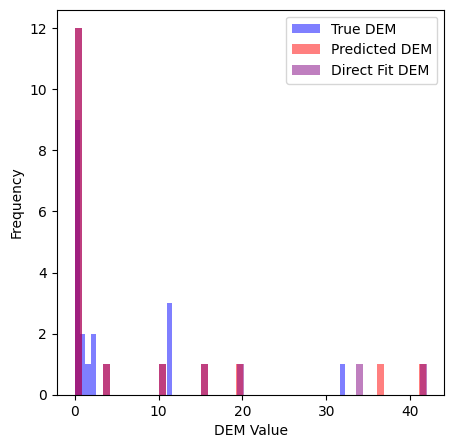

In [60]:
plt.figure(figsize=(5, 5))
plt.hist(dem_true.flatten(), bins=50, color="blue", alpha=0.5, label="True DEM")
plt.hist(dem_pred_cube.flatten(), bins=50, color="red", alpha=0.5, label="Predicted DEM")
plt.hist(dem_pred_direct.flatten(), bins=50, color="purple", alpha=0.5, label="Direct Fit DEM")
plt.xlabel("DEM Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

---
## MÉTODO 3: LP clásico (Basis Pursuit exacto)

El método LP resuelve exactamente:

$$\min_{\mathbf{x} \geq 0} \|\mathbf{x}\|_1 \quad \text{s.t.} \quad \mathbf{l} \leq D\mathbf{x} \leq \mathbf{u}$$

usando el solver HiGHS. Garantiza factibilidad exacta (las restricciones se satisfacen con precisión de máquina).

In [61]:
import sys
sys.path.append('../scripts') 

In [62]:
from fullBP import invertDEMCube

args_lp = SimpleNamespace(fitfn="lp", parallel=0, tolfac=1.4, zerochill=True)

# invertDEMCube espera [C, H, W] — pasamos el píxel como imagen 1x1
DEMC_lp = invertDEMCube(
    aia_input.squeeze(0).cpu().numpy(),   # [6, 1, 1]
    aia_errors.squeeze(0).cpu().numpy(),  # [6, 1, 1]
    RData,
    args=args_lp
)  # devuelve [18, 1, 1]

x_lp = torch.tensor(DEMC_lp[:, 0, 0], dtype=torch.float64).unsqueeze(0)  # [1, 18] — ya es xi, no x

print("DEMC_lp shape:", DEMC_lp.shape)
print("L1 norm (DEM):", np.sum(np.abs(DEMC_lp)))

# verificar factibilidad
Dx_lp = torch.tensor(R_np @ DEMC_lp[:, 0, 0], dtype=torch.float64).unsqueeze(0)  # [1, 6]
ub_viol_lp = torch.sum(torch.relu(lb.double() - Dx_lp)).item()
lb_viol_lp = torch.sum(torch.relu(Dx_lp - ub.double())).item()
print(f"UB viol: {ub_viol_lp:.6f} | LB viol: {lb_viol_lp:.6f}")

Setup took 0.00
Skipping relaxation step
BP took 0.03
Repacking took 0.00
DEMC_lp shape: (18, 1, 1)
L1 norm (DEM): 74.991325736761
UB viol: 0.000000 | LB viol: 0.000000


---
## Comparación de los tres métodos

Para comparar, reconstruimos la DEM $\hat{\boldsymbol{\xi}} = B\mathbf{x}$ desde los coeficientes de los métodos 1 y 2, y calculamos la resíntesis $\hat{\mathbf{y}} = R\hat{\boldsymbol{\xi}}$ para los tres.

El método 3 ya devuelve $\boldsymbol{\xi}$ directamente.

In [63]:
def coeffs_to_dem(x_flat, B):
    """Convierte coeficientes de base x [1, 54] a DEM xi [18]"""
    with torch.no_grad():
        xi = torch.matmul(x_flat, B.T)  # [1, 18]
    return xi.squeeze().cpu().numpy()  # [18]

def dem_to_resynth(xi, R):
    """Resíntesis: y_hat = R @ xi.  xi: [18], R: [6, 18] -> [6]"""
    return R @ np.maximum(0, xi)

In [64]:
# DEM de cada método
xi_net    = coeffs_to_dem(x_net_flat, B)          # método 1
xi_net_fit = coeffs_to_dem(x_net_fit_flat, B)      # método 1 con fit
xi_direct = coeffs_to_dem(x_direct, B)            # método 2
xi_lp     = DEMC_lp[:, 0, 0]                      # método 3 (ya es xi)
xi_true   = dem_true_pixel                        # ground truth

# resíntesis5
y_obs      = aia_obs_flat.squeeze().cpu().numpy()  # observaciones reales
y_net      = dem_to_resynth(xi_net,    R_np)
y_net_fit  = dem_to_resynth(xi_net_fit, R_np)
y_direct   = dem_to_resynth(xi_direct, R_np)
y_lp       = dem_to_resynth(xi_lp,     R_np)
y_true     = dem_to_resynth(xi_true,   R_np)

print(f"{'Método':<20} {'MAE DEM':>12} {'MAE Resynth':>14}")
print("-" * 48)
for name, xi, y in [("Red neuronal", xi_net, y_net),
                    ("Red con fit", xi_net_fit, y_net_fit),
                    ("Optim. directa", xi_direct, y_direct),
                    ("LP clásico", xi_lp, y_lp),
                    ("Ground truth", xi_true, y_true)]:
    mae_dem    = np.mean(np.abs(xi - xi_true))
    mae_resynth = np.mean(np.abs(y - y_obs))
    print(f"{name:<20} {mae_dem:>12.4f} {mae_resynth:>14.4f}")

Método                    MAE DEM    MAE Resynth
------------------------------------------------
Red neuronal               6.5576        35.7093
Red con fit                4.1804        22.6162
Optim. directa             6.3665        32.7232
LP clásico                 1.1633        23.5137
Ground truth               0.0000        29.8822


## Visualización: DEM de los tres métodos vs. ground truth

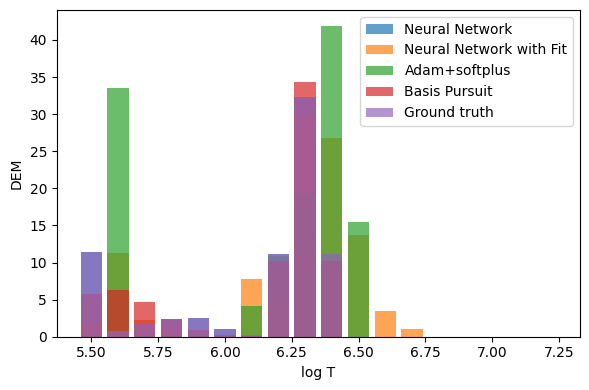

In [67]:
plt.figure(figsize=(6, 4))

plt.bar(logT, xi, width=0.08, alpha=0.7, label="Neural Network")
plt.bar(logT, xi_net_fit, width=0.08, alpha=0.7, label="Neural Network with Fit")
plt.bar(logT, xi_direct, width=0.08, alpha=0.7, label="Adam+softplus")
plt.bar(logT, xi_lp, width=0.08, alpha=0.7, label="Basis Pursuit")
plt.bar(logT, xi_true, width=0.08, alpha=0.7, label="Ground truth")
 
plt.ylabel("DEM")
plt.xlabel("log T")

plt.legend()
plt.tight_layout()
plt.savefig("dem_comparison.png", dpi=300, bbox_inches='tight')
plt.show()